In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

performance = pd.read_csv(
    r"C:\Users\HP\Desktop\Mutual_Fund_Analytics\data\raw\07_scheme_performance.csv"
)

metrics_df = pd.read_csv(
    r"C:\Users\HP\Desktop\Mutual_Fund_Analytics\data\processed\performance_metrics.csv"
)

performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [2]:
performance.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')

In [3]:
metrics_df.columns

Index(['amfi_code', 'scheme_name', 'cagr', 'volatility', 'sharpe_ratio',
       'sortino_ratio', 'max_drawdown', 'var_95'],
      dtype='object')

# Alpha vs Beta Analysis

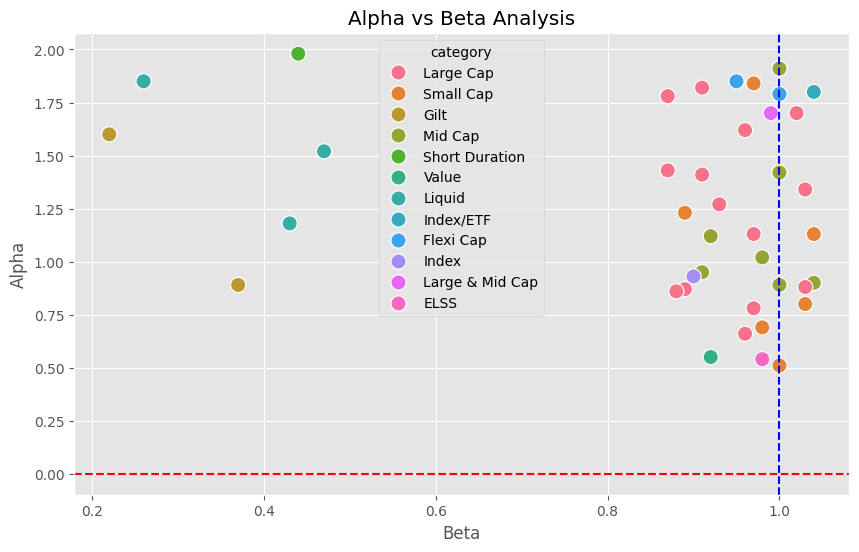

In [4]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=performance,
    x="beta",
    y="alpha",
    hue="category",
    s=120
)

plt.axhline(0,color="red",linestyle="--")
plt.axvline(1,color="blue",linestyle="--")

plt.title("Alpha vs Beta Analysis")
plt.xlabel("Beta")
plt.ylabel("Alpha")
plt.show()

In [5]:
category_perf = (
    performance
    .groupby("category")
    ["return_3yr_pct"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

category_perf

,category,return_3yr_pct
0,Small Cap,21.686667
1,Mid Cap,16.590000
2,Flexi Cap,15.495000
3,Value,14.760000
4,Large & Mid Cap,14.560000
5,ELSS,13.580000
6,Large Cap,12.985714
7,Index,12.100000
8,Index/ETF,11.770000
9,Short Duration,7.370000


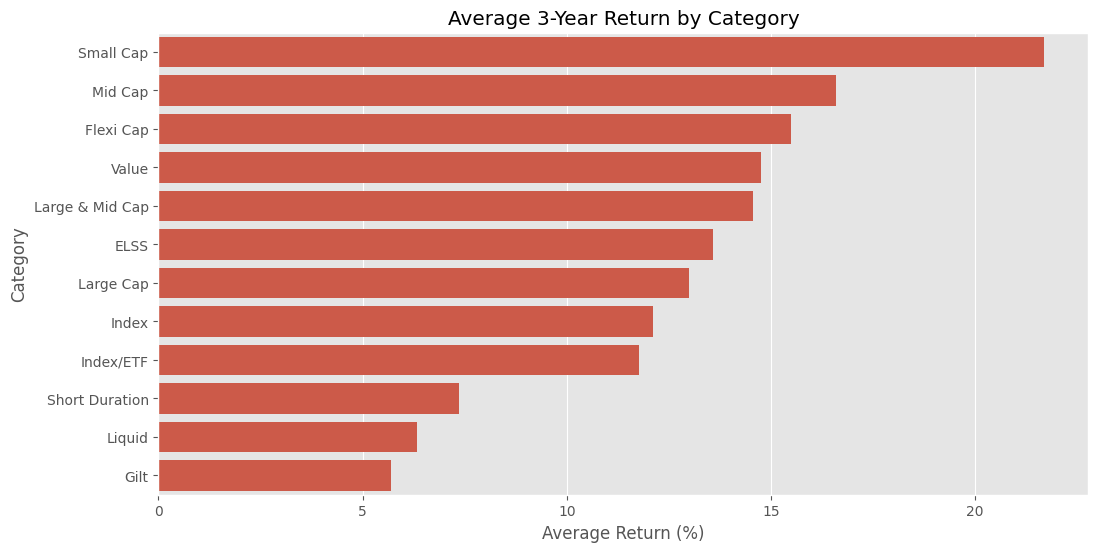

In [6]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=category_perf,
    x="return_3yr_pct",
    y="category"
)

plt.title("Average 3-Year Return by Category")
plt.xlabel("Average Return (%)")
plt.ylabel("Category")

plt.show()

In [7]:
merged_df = performance.merge(
    metrics_df,
    on=["amfi_code", "scheme_name"],
    how="inner"
)

merged_df.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,cagr,volatility,sharpe_ratio_y,sortino_ratio_y,max_drawdown,var_95
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,...,14288,1.54,4,Moderate,24.772562,13.741434,1.366128,2.419896,-15.012385,-1.284623
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,...,1231,0.66,3,Moderate,20.677048,13.939368,1.052921,1.778038,-11.803494,-1.350097
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,19259,1.43,5,Very High,31.095664,25.140579,0.998213,1.769077,-28.706006,-2.450705
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,36061,0.72,4,Very High,1.980032,24.950125,-0.161120,-0.265931,-52.574221,-2.685944
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,...,24101,0.77,5,Low,5.672189,3.967062,-0.082633,-0.137409,-4.328729,-0.393828


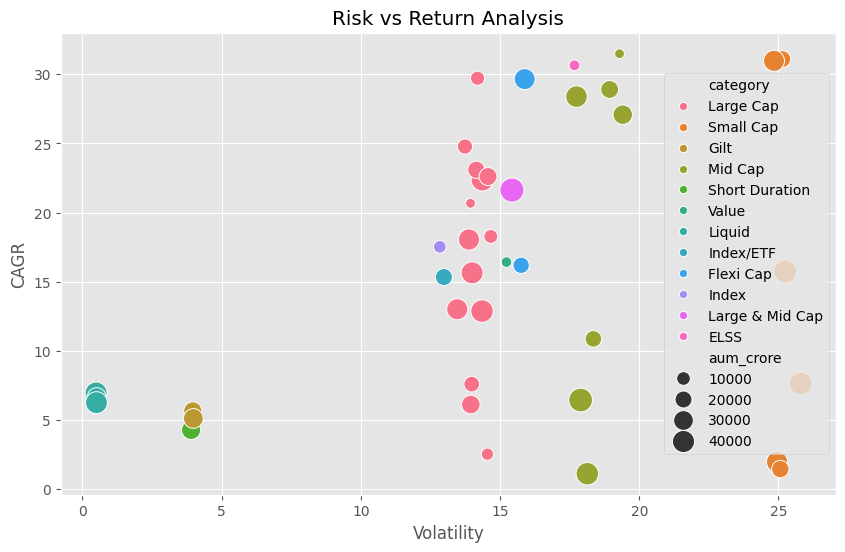

In [8]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=merged_df,
    x="volatility",
    y="cagr",
    hue="category",
    size="aum_crore",
    sizes=(50,300)
)

plt.title("Risk vs Return Analysis")
plt.xlabel("Volatility")
plt.ylabel("CAGR")

plt.show()

# Mutual Fund Recommendation Engine

In [9]:
merged_df.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio_x',
       'sortino_ratio_x', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore',
       'expense_ratio_pct', 'morningstar_rating', 'risk_grade', 'cagr',
       'volatility', 'sharpe_ratio_y', 'sortino_ratio_y', 'max_drawdown',
       'var_95'],
      dtype='object')

In [10]:
merged_df[
    [
        "scheme_name",
        "sharpe_ratio_x",
        "sharpe_ratio_y"
    ]
].head()

,scheme_name,sharpe_ratio_x,sharpe_ratio_y
0,SBI Bluechip Fund - Regular Plan - Growth,0.88,1.366128
1,SBI Bluechip Fund - Direct Plan - Growth,0.81,1.052921
2,SBI Small Cap Fund - Regular Plan - Growth,0.94,0.998213
3,SBI Small Cap Fund - Direct Plan - Growth,0.93,-0.161120
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52,-0.082633


In [11]:
merged_df = merged_df.rename(
    columns={
        "sharpe_ratio_y": "sharpe_ratio",
        "sortino_ratio_y": "sortino_ratio"
    }
)

In [12]:
merged_df.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio_x',
       'sortino_ratio_x', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore',
       'expense_ratio_pct', 'morningstar_rating', 'risk_grade', 'cagr',
       'volatility', 'sharpe_ratio', 'sortino_ratio', 'max_drawdown',
       'var_95'],
      dtype='object')

In [13]:
recommendation_df = merged_df.copy()

recommendation_df["score"] = (
    recommendation_df["cagr"] * 0.4 +
    recommendation_df["sharpe_ratio"] * 30 -
    recommendation_df["volatility"] * 0.2
)

top_recommendations = (
    recommendation_df[
        ["scheme_name", "category", "score"]
    ]
    .sort_values(
        by="score",
        ascending=False
    )
    .head(10)
)

top_recommendations

,scheme_name,category,score
14,ICICI Pru Liquid Fund - Regular - Growth,Liquid,61.543524
34,Mirae Asset Large Cap Fund - Regular - Growth,Large Cap,59.164019
22,Kotak Flexicap Fund - Regular - Growth,Flexi Cap,53.338014
36,Mirae Asset Tax Saver Fund - Regular - Growth,ELSS,50.552075
12,ICICI Pru Midcap Fund - Regular - Growth,Mid Cap,48.360790
0,SBI Bluechip Fund - Regular Plan - Growth,Large Cap,48.144586
38,DSP Midcap Fund - Regular - Growth,Mid Cap,45.639748
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Mid Cap,44.050174
15,Nippon India Large Cap Fund - Regular - Growth,Large Cap,42.653382
23,Kotak Liquid Fund - Regular - Growth,Liquid,41.076862


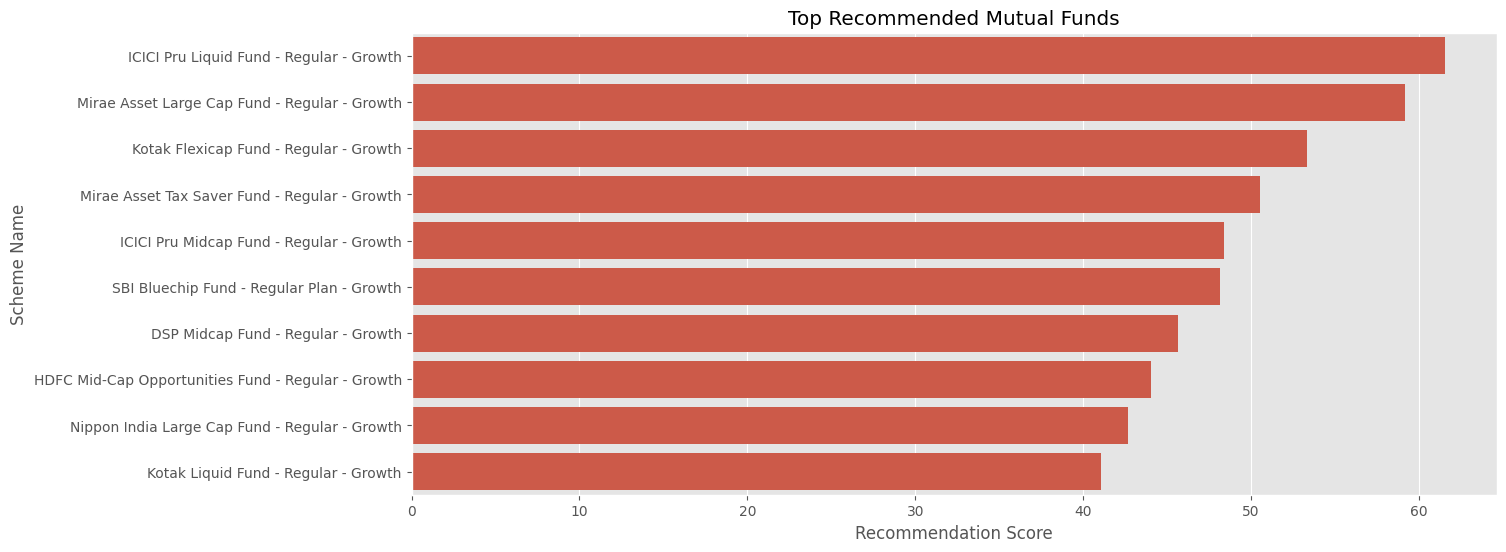

In [14]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=top_recommendations,
    x="score",
    y="scheme_name"
)

plt.title("Top Recommended Mutual Funds")
plt.xlabel("Recommendation Score")
plt.ylabel("Scheme Name")

plt.show()

# Category Ranking Analysis

In [15]:
category_ranking = (
    merged_df
    .groupby("category")
    .agg({
        "return_3yr_pct": "mean",
        "alpha": "mean",
        "sharpe_ratio": "mean",
        "aum_crore": "mean"
    })
    .round(2)
    .sort_values(
        by="return_3yr_pct",
        ascending=False
    )
)

category_ranking

,return_3yr_pct,alpha,sharpe_ratio,aum_crore
category,,,,
Small Cap,21.69,1.03,0.35,32872.00
Mid Cap,16.59,1.17,0.70,28426.29
Flexi Cap,15.50,1.82,1.07,26462.00
Value,14.76,0.55,0.68,2571.00
Large & Mid Cap,14.56,1.70,1.01,49046.00
ELSS,13.58,0.54,1.39,2989.00
Large Cap,12.99,1.25,0.78,23176.14
Index,12.10,0.93,0.90,7350.00
Index/ETF,11.77,1.80,0.72,20284.00


In [16]:
category_ranking.to_csv(
    r"C:\Users\HP\Desktop\Mutual_Fund_Analytics\data\processed\category_ranking.csv"
)

In [17]:
top_recommendations.to_csv(
    r"C:\Users\HP\Desktop\Mutual_Fund_Analytics\data\processed\top_recommendations.csv",
    index=False
)